In [1]:
import requests
import json
from datetime import datetime, timedelta, timezone
from datetime import timezone
import time
import random
import asyncio, aiohttp
import matplotlib.pyplot as plt
from collections import defaultdict

_TOKEN_CACHE = None  # global cache

def get_session_token():
    global _TOKEN_CACHE
    if _TOKEN_CACHE:   # reuse valid token
        return _TOKEN_CACHE

    url = "https://bsky.social/xrpc/com.atproto.server.createSession"
    handle = "repostproj.bsky.social"
    app_password = "vyvc-xg5q-seda-utaz" 

    for _ in range(3):  # retry a few times on rate limit
        r = requests.post(url, json={"identifier": handle, "password": app_password})
        if r.status_code == 429:
            print("⚠️ Rate-limited on login, sleeping 5s...")
            time.sleep(1)
            continue
        r.raise_for_status()
        _TOKEN_CACHE = r.json()["accessJwt"]
        return _TOKEN_CACHE

    raise RuntimeError("Failed to obtain token after retries")


In [ ]:
def fmt(dt):
    """Convert datetime → Bluesky timestamp format."""
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.strftime("%Y-%m-%dT%H:%M:%S.000Z")


def parse_dt(created):
    """Parse Bluesky createdAt → naive UTC datetime."""
    return (
        datetime.fromisoformat(created.replace("Z", "+00:00"))
        .astimezone(timezone.utc)
        .replace(tzinfo=None)
    )

In [75]:
def fetch_posts(
    queries,
    since_dt,
    until_dt,
    outfile,
    max_posts=10000,
    min_posts=0
):
    url = "https://bsky.social/xrpc/app.bsky.feed.searchPosts"
    token = get_session_token()

    session = requests.Session()
    session.headers.update({"Authorization": f"Bearer {token}"})

    grand_total = 0

    with open(outfile, "w", encoding="utf-8") as f:

        for query in queries:

            total = 0
            last_print = 0
            cursor = None
            stop_pagination = False

            while True:
                params = {
                   "q": query,
                    "limit": 100,
                    "sort": "latest",
                    "since": fmt(since_dt),
                    "until": fmt(until_dt),
                    "lang": "en"
                }

                if cursor:
                    params["cursor"] = cursor
                else:
                    # still pass bounds to API (helps reduce noise)
                    params["since"] = fmt(since_dt)
                    params["until"] = fmt(until_dt)

                r = session.get(url, params=params)

                if r.status_code == 429:
                    time.sleep(1)
                    continue

                if r.status_code != 200:
                    break

                data = r.json()
                posts = data.get("posts", [])

                if not posts:
                    break

                for p in posts:
                    created = parse_dt(p["record"]["createdAt"])

                    # STRICT WINDOW ENFORCEMENT
                    if not (since_dt <= created <= until_dt):
                        if created < since_dt:
                            stop_pagination = True
                            break
                        continue

                    p["-hashtag"] = query
                    f.write(json.dumps(p, ensure_ascii=False) + "\n")

                    total += 1
                    grand_total += 1

                    if total - last_print >= 5000:
                        print(
                            f"\r[{query}] Collected {total} posts so far...",
                            end="",
                            flush=True
                        )
                        last_print = total

                    if max_posts and total >= max_posts:
                        stop_pagination = True
                        break

                if stop_pagination:
                    break

                cursor = data.get("cursor")
                if not cursor:
                    break

            print()

            if total < min_posts:
                raise ValueError(
                    f"Query '{query}' returned only {total} posts "
                    f"(minimum required: {min_posts})"
                )

    print(f"\nCollected {grand_total} posts in total.")

    return grand_total


In [79]:
def fetch_posts(
    query,
    since_dt,
    until_dt,
    outfile,
    max_posts=None,
    min_posts=0
):
    """
    Fetch ALL posts the Bluesky index returns between since_dt and until_dt.
    Continues by stepping `until` backward using the oldest timestamp.
    Raises ValueError if fewer than min_posts are collected.
    """

    url = "https://bsky.social/xrpc/app.bsky.feed.searchPosts"
    token = get_session_token()

    headers = {"Authorization": f"Bearer {token}"}

    current_until = until_dt
    total = 0
    last_print = 0

    with open(outfile, "w", encoding="utf-8") as f:

        while True:
            params = {
                "q": query,
                "limit": 100,
                "sort": "latest",
                "since": fmt(since_dt),
                "until": fmt(current_until),
                "lang": "en"
            }

            r = requests.get(url, headers=headers, params=params)

            if r.status_code in (429, 502):
                time.sleep(1)
                continue

            if r.status_code != 200:
                break

            data = r.json()
            posts = data.get("posts", [])

            if not posts:
                break

            for p in posts:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")
                total += 1

                if total - last_print >= 2000:
                    print(f"\rCollected {total} posts so far…", end="", flush=True)
                    last_print = total

                if max_posts and total >= max_posts:
                    break

            oldest_ts = posts[-1]["record"]["createdAt"]
            oldest_dt = parse_dt(oldest_ts)

            if oldest_dt <= since_dt or (max_posts and total >= max_posts):
                break

            current_until = oldest_dt

    if total < min_posts:
        raise ValueError(
            f"Query '{query}' returned only {total} posts "
            f"(minimum required: {min_posts})"
        )

    return total

def collect_hashtags_posts(
    hashtags,
    since_dt,
    until_dt,
    max_posts_per_hashtag,
    min_posts_per_hashtag
):
    for h in hashtags:
        file = f"{h}.jsonl"
        query = f"#{h}"

        fetch_posts(
            query=query,
            since_dt=since_dt,
            until_dt=until_dt,
            outfile=file,
            max_posts=max_posts_per_hashtag,
            min_posts=min_posts_per_hashtag
        )

In [ ]:
collect_hashtags_posts(
    hashtags= ["Trump", "Minneapolis", "GoldenGlobes", "AI", "TheTraitors", "booksky", "gaza", "aew", "Pokemon", "superbowl", "olympics", "art"],
    since_dt=datetime(2026, 1, 1),
    until_dt=datetime(2026, 2, 20),
    max_posts_per_hashtag = 20000,
    min_posts_per_hashtag = 10000
)

Collected 10000 posts so far…

KeyboardInterrupt: 

In [81]:
file="StateOfPlay.jsonl"

In [82]:


def get_post_day_stats():
    stats = defaultdict(lambda: {
        "count": 0,
        "min_hour": None,
        "max_hour": None,
        "total_reposts": 0,
        "avg_reposts_per_post": 0.0
    })

    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                p = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (p.get("record") or {}).get("createdAt")
            if not created:
                continue

            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except Exception:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except Exception:
                    continue

            day = dt.date().isoformat()
            hour = dt.hour

            stats[day]["count"] += 1
            stats[day]["total_reposts"] += p.get("repostCount", 0) or 0

            if stats[day]["min_hour"] is None or hour < stats[day]["min_hour"]:
                stats[day]["min_hour"] = hour

            if stats[day]["max_hour"] is None or hour > stats[day]["max_hour"]:
                stats[day]["max_hour"] = hour

    # Print results (sorted by day)
    for day in sorted(stats):
        d = stats[day]
        avg = round(d["total_reposts"] / d["count"], 2) if d["count"] > 0 else 0.0

        print(
            f"{day} | "
            f"posts={d['count']} | "
            f"hours={d['min_hour']}-{d['max_hour']} | "
            f"total_reposts={d['total_reposts']} | "
            f"avg_reposts_per_post={avg}"
        )

    return

get_post_day_stats()

2026-01-26 | posts=5 | hours=6-22 | total_reposts=0 | avg_reposts_per_post=0.0
2026-01-27 | posts=2 | hours=4-12 | total_reposts=2 | avg_reposts_per_post=1.0
2026-01-28 | posts=1 | hours=11-11 | total_reposts=0 | avg_reposts_per_post=0.0
2026-01-29 | posts=1 | hours=10-10 | total_reposts=0 | avg_reposts_per_post=0.0
2026-01-30 | posts=1 | hours=2-2 | total_reposts=0 | avg_reposts_per_post=0.0
2026-01-31 | posts=1 | hours=17-17 | total_reposts=0 | avg_reposts_per_post=0.0
2026-02-01 | posts=1 | hours=8-8 | total_reposts=0 | avg_reposts_per_post=0.0
2026-02-03 | posts=1 | hours=11-11 | total_reposts=0 | avg_reposts_per_post=0.0
2026-02-06 | posts=1 | hours=19-19 | total_reposts=1 | avg_reposts_per_post=1.0
2026-02-07 | posts=1 | hours=23-23 | total_reposts=0 | avg_reposts_per_post=0.0
2026-02-08 | posts=1 | hours=21-21 | total_reposts=0 | avg_reposts_per_post=0.0
2026-02-09 | posts=35 | hours=12-22 | total_reposts=35 | avg_reposts_per_post=1.0
2026-02-10 | posts=17 | hours=1-17 | total_r

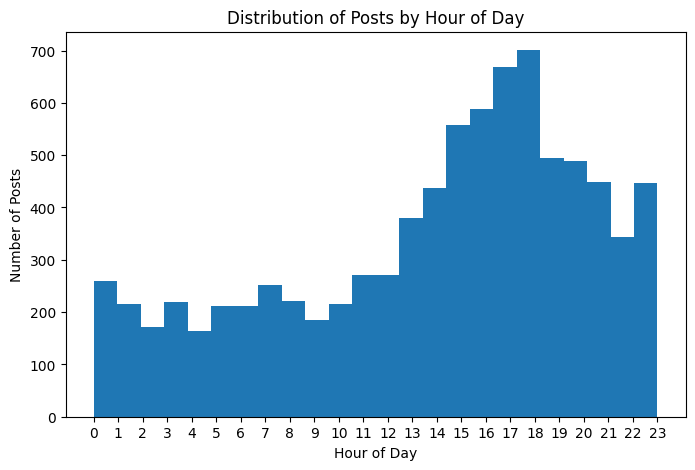

In [55]:



def plot_posts_by_hour(file_path):
    """
    Reads a .jsonl file of Bluesky posts and plots:
        Number of posts  vs  Hour of the day (0–23)
    """
    hours = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (post.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            hours.append(dt.hour)

    # Plot
    plt.figure(figsize=(8,5))
    plt.hist(hours, bins=24)
    plt.xlabel("Hour of Day")
    plt.ylabel("Number of Posts")
    plt.title("Distribution of Posts by Hour of Day")
    plt.xticks(range(24))
    plt.show()

plot_posts_by_hour(file)


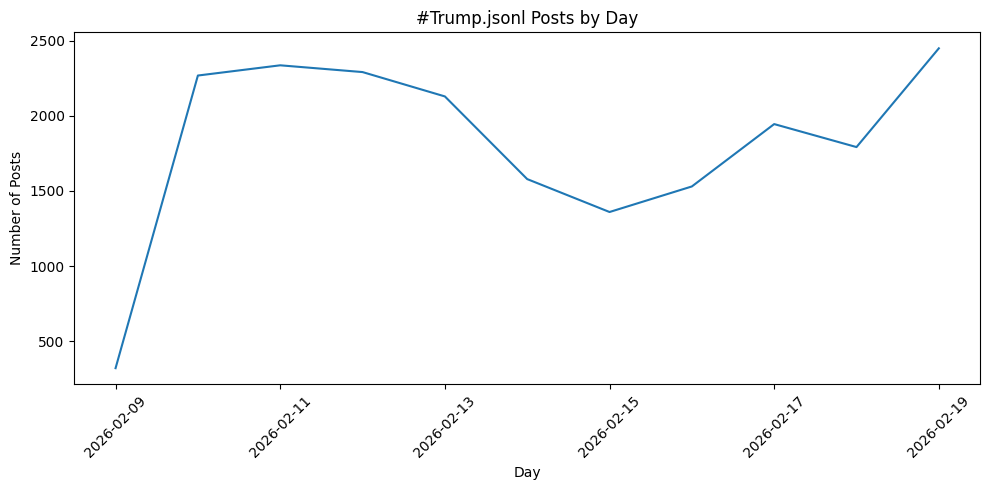

In [72]:

from collections import Counter


def plot_posts_by_day(file_path):
    """
    Reads a .jsonl file of Bluesky posts and plots:
        Number of posts vs Day
    """
    dates = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                post = json.loads(line)
            except json.JSONDecodeError:
                continue

            created = (post.get("record") or {}).get("createdAt")
            if not created:
                continue

            # Parse timestamp safely
            try:
                dt = datetime.fromisoformat(created.replace("Z", "+00:00"))
            except:
                try:
                    dt = datetime.fromisoformat(created[:19])
                except:
                    continue

            dates.append(dt.date())

    # Count posts per day
    counts = Counter(dates)
    days = sorted(counts.keys())
    values = [counts[d] for d in days]

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(days, values)
    plt.xlabel("Day")
    plt.ylabel("Number of Posts")
    plt.title(f"#{file_path} Posts by Day")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_posts_by_day(file)
